In [1]:
import numpy as np


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


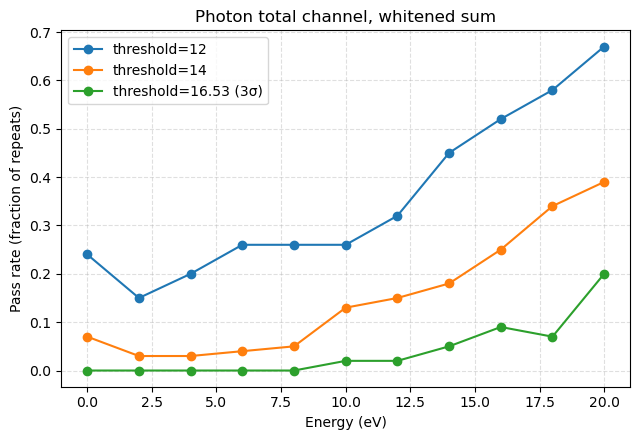


Pass rates:
Energy           12          14       16.53 (3σ)
0            0.2400     0.0700     0.0000
2            0.1500     0.0300     0.0000
4            0.2000     0.0300     0.0000
6            0.2600     0.0400     0.0000
8            0.2600     0.0500     0.0000
10           0.2600     0.1300     0.0200
12           0.3200     0.1500     0.0200
14           0.4500     0.1800     0.0500
16           0.5200     0.2500     0.0900
18           0.5800     0.3400     0.0700
20           0.6700     0.3900     0.2000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Settings ---
base_dir = Path("/home/dwong/DELight_mtr/flattened_sum/max_amp")
thresholds = [12, 14, 16.53]   # pass if amplitude >= threshold
special_thr = 16.53
special_note = " (3σ)"

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_vacsum_energy_*.npy")
)
file_tmpl = "max_amplitudes_vacsum_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape: (repeats,) == (100,)
    data = np.asarray(data).squeeze()

    if data.ndim != 1:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected 1D array of length 100)")
    if data.shape[0] != 100:
        print(f"[warn] Unexpected length in {path}: {data.shape[0]} (expected 100)")

    available_E.append(E)
    for thr in thresholds:
        passes = (data >= thr)
        pass_rate = passes.mean()
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    label = f"threshold={thr}"
    if thr == special_thr:
        label += special_note
    plt.plot(available_E, pass_rates[thr], marker="o", label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate (fraction of repeats)")
plt.title("Photon total channel, whitened sum")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --- (Optional) print a small table ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join(
    [f"{thr:>10}" + (special_note if thr == special_thr else "") for thr in thresholds]
)
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


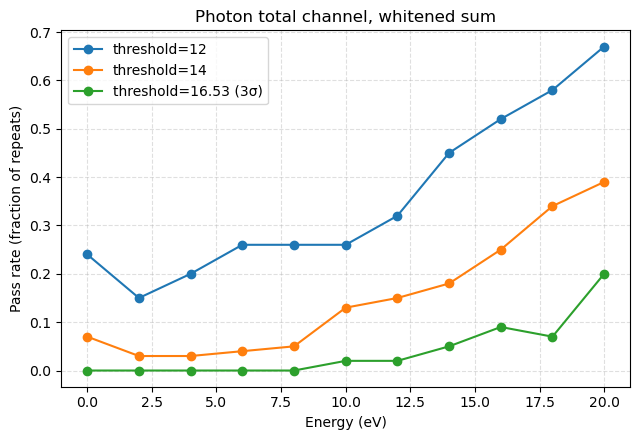


Pass rates:
Energy           12          14       16.53 (3σ)
0            0.2400     0.0700     0.0000
2            0.1500     0.0300     0.0000
4            0.2000     0.0300     0.0000
6            0.2600     0.0400     0.0000
8            0.2600     0.0500     0.0000
10           0.2600     0.1300     0.0200
12           0.3200     0.1500     0.0200
14           0.4500     0.1800     0.0500
16           0.5200     0.2500     0.0900
18           0.5800     0.3400     0.0700
20           0.6700     0.3900     0.2000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Settings ---
base_dir = Path("/home/dwong/DELight_mtr/flattened_sum/max_amp")
thresholds = [12, 14, 16.53]   # pass if amplitude >= threshold
special_thr = 16.53
special_note = " (3σ)"

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_vacsum_energy_*.npy")
)
file_tmpl = "max_amplitudes_vacsum_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape: (repeats,) == (100,)
    data = np.asarray(data).squeeze()

    if data.ndim != 1:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected 1D array of length 100)")
    if data.shape[0] != 100:
        print(f"[warn] Unexpected length in {path}: {data.shape[0]} (expected 100)")

    available_E.append(E)
    for thr in thresholds:
        passes = (data >= thr)
        pass_rate = passes.mean()
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    label = f"threshold={thr}"
    if thr == special_thr:
        label += special_note
    plt.plot(available_E, pass_rates[thr], marker="o", label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate (fraction of repeats)")
plt.title("Photon total channel, whitened sum")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --- (Optional) print a small table ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join(
    [f"{thr:>10}" + (special_note if thr == special_thr else "") for thr in thresholds]
)
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


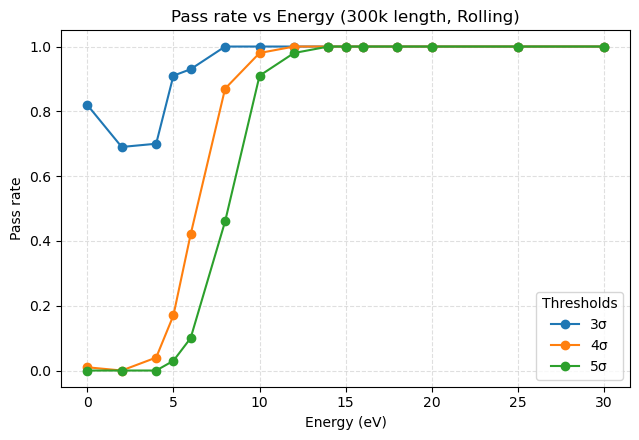


Pass rates:
Energy           3σ          4σ          5σ
0            0.8200     0.0100     0.0000
2            0.6900     0.0000     0.0000
4            0.7000     0.0400     0.0000
5            0.9100     0.1700     0.0300
6            0.9300     0.4200     0.1000
8            1.0000     0.8700     0.4600
10           1.0000     0.9800     0.9100
12           1.0000     1.0000     0.9800
14           1.0000     1.0000     1.0000
15           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000
25           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("/ceph/dwong/trigger_samples/v2_300k/max_amp")
import re
from pathlib import Path

base_dir = Path("/ceph/dwong/trigger_samples/v2_300k/max_amp")
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], marker="o", label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (300k length, Rolling)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


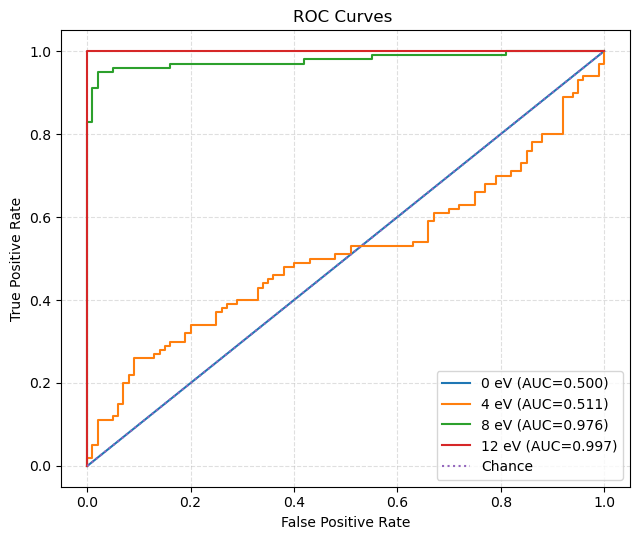

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------
# Settings
# --------------------
base_dir = Path("/ceph/dwong/trigger_samples/v2_300k/max_amp")
neg_energy = 0
pos_energies = [0,4, 8, 12]  # adjust if needed
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --------------------
# Helpers
# --------------------
def load_event_scores(path: Path) -> np.ndarray:
    """
    Load (R, 56) array and reduce to event-level score by taking
    the max across channels. Returns shape (R,).
    """
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {arr.shape} (expected (R, 56))")
    # event score = max over channels
    return arr.max(axis=1)

def roc_from_scores(neg_scores: np.ndarray, pos_scores: np.ndarray):
    """
    Build ROC (FPR, TPR) by sweeping a threshold across all observed scores.
    Uses '>= threshold' as the positive decision rule.
    Returns FPR, TPR, thresholds (sorted by descending threshold).
    """
    # thresholds = unique score values across both classes
    thresholds = np.unique(np.concatenate([neg_scores, pos_scores]))
    thresholds = thresholds[::-1]  # descending

    # Pre-sort for vectorization if desired (simple loop is clear and fast enough here)
    n_neg = neg_scores.size
    n_pos = pos_scores.size

    TPR = []
    FPR = []
    for thr in thresholds:
        tp = (pos_scores >= thr).sum()
        fp = (neg_scores >= thr).sum()
        TPR.append(tp / n_pos if n_pos else 0.0)
        FPR.append(fp / n_neg if n_neg else 0.0)

    # Ensure ROC starts at (0,0) and ends at (1,1)
    # (Not strictly necessary, but helps with nice plotting/integration edge cases.)
    if thresholds.size == 0:
        return np.array([0.0]), np.array([0.0]), np.array([])
    FPR = np.r_[0.0, FPR, 1.0]
    TPR = np.r_[0.0, TPR, 1.0]
    return np.array(FPR), np.array(TPR), thresholds

def auc_trapezoid(x: np.ndarray, y: np.ndarray) -> float:
    """
    Standard AUC via trapezoidal rule; assumes x is FPR ascending.
    """
    # Sort by FPR ascending just in case
    order = np.argsort(x)
    return np.trapz(y[order], x[order])

# --------------------
# Load negatives (noise)
# --------------------
neg_path = base_dir / file_tmpl.format(E=neg_energy)
if not neg_path.exists():
    raise FileNotFoundError(f"Missing background (negatives) file: {neg_path}")

neg_scores = load_event_scores(neg_path)

# --------------------
# Build ROC per energy + optional micro-average
# --------------------
plt.figure(figsize=(6.5, 5.5))

aucs = {}
all_pos_scores = []

for E in pos_energies:
    pos_path = base_dir / file_tmpl.format(E=E)
    if not pos_path.exists():
        print(f"[warn] Missing signal file for {E} eV, skipping: {pos_path}")
        continue

    pos_scores = load_event_scores(pos_path)
    all_pos_scores.append(pos_scores)

    FPR, TPR, _ = roc_from_scores(neg_scores, pos_scores)
    auc = auc_trapezoid(FPR, TPR)
    aucs[E] = auc

    plt.plot(FPR, TPR, label=f"{E} eV (AUC={auc:.3f})")

# Optional: micro-average across all signal energies (concatenate all positives)


# Chance line
plt.plot([0, 1], [0, 1], linestyle=":", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves ")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()




[warn] 0 eV is the background set; skipping as a positive class.


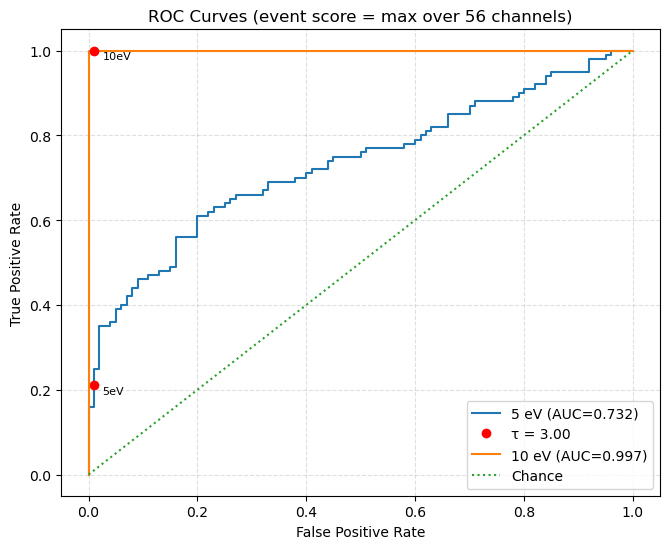


AUC by energy:
   5 eV : 0.7323
  10 eV : 0.9974


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------
# Settings
# --------------------
base_dir = Path("/ceph/dwong/trigger_samples/v2_300k/max_amp")
neg_energy = 0
pos_energies = [0, 5, 10]  # if 0 is included, we'll skip it below
file_tmpl = "max_amplitudes_energy_{E}.npy"

# threshold to highlight on ROC
highlight_thr = 3.0

# --------------------
# Helpers
# --------------------
def load_event_scores(path: Path) -> np.ndarray:
    """
    Load (R, 56) array and reduce to an event-level score by taking
    the max across channels. Returns shape (R,).
    """
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {arr.shape} (expected (R, 56))")
    return arr.max(axis=1)

def roc_from_scores(neg_scores: np.ndarray, pos_scores: np.ndarray):
    """
    Build ROC (FPR, TPR) by sweeping a threshold across all observed scores.
    Uses '>= threshold' as the positive decision rule.
    Returns FPR, TPR, thresholds (sorted by descending threshold).
    """
    thresholds = np.unique(np.concatenate([neg_scores, pos_scores]))[::-1]  # descending
    n_neg = neg_scores.size
    n_pos = pos_scores.size

    TPR = []
    FPR = []
    for thr in thresholds:
        tp = (pos_scores >= thr).sum()
        fp = (neg_scores >= thr).sum()
        TPR.append(tp / n_pos if n_pos else 0.0)
        FPR.append(fp / n_neg if n_neg else 0.0)

    if thresholds.size == 0:
        return np.array([0.0]), np.array([0.0]), np.array([])
    FPR = np.r_[0.0, FPR, 1.0]
    TPR = np.r_[0.0, TPR, 1.0]
    return np.array(FPR), np.array(TPR), thresholds

def auc_trapezoid(x: np.ndarray, y: np.ndarray) -> float:
    """Standard AUC via trapezoidal rule; assumes x is FPR ascending."""
    order = np.argsort(x)
    return np.trapz(y[order], x[order])

# --------------------
# Load negatives (noise)
# --------------------
neg_path = base_dir / file_tmpl.format(E=neg_energy)
if not neg_path.exists():
    raise FileNotFoundError(f"Missing background (negatives) file: {neg_path}")
neg_scores = load_event_scores(neg_path)

# --------------------
# Build ROC per energy and mark the threshold=3 operating point
# --------------------
plt.figure(figsize=(6.8, 5.6))

aucs = {}
added_marker_legend = False  # to avoid duplicate legend entries for the red dot

for E in pos_energies:
    if E == neg_energy:
        print(f"[warn] {E} eV is the background set; skipping as a positive class.")
        continue

    pos_path = base_dir / file_tmpl.format(E=E)
    if not pos_path.exists():
        print(f"[warn] Missing signal file for {E} eV, skipping: {pos_path}")
        continue

    pos_scores = load_event_scores(pos_path)

    # Full ROC
    FPR, TPR, _ = roc_from_scores(neg_scores, pos_scores)
    auc = auc_trapezoid(FPR, TPR)
    aucs[E] = auc
    plt.plot(FPR, TPR, label=f"{E} eV (AUC={auc:.3f})")

    # Highlight the operating point at threshold = highlight_thr
    fpr_thr = (neg_scores >= highlight_thr).mean()
    tpr_thr = (pos_scores >= highlight_thr).mean()

    if not added_marker_legend:
        plt.plot(fpr_thr, tpr_thr, marker="o", linestyle="None", color="red", label=f"τ = {highlight_thr:.2f}")
        added_marker_legend = True
    else:
        plt.plot(fpr_thr, tpr_thr, marker="o", linestyle="None", color="red")

    # Optional tiny text label near each red dot
    plt.annotate(f"{E}eV", (fpr_thr, tpr_thr), textcoords="offset points", xytext=(6, -6), fontsize=8)

# Chance line
plt.plot([0, 1], [0, 1], linestyle=":", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (event score = max over 56 channels)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------
# Print AUCs
# --------------------
if aucs:
    print("\nAUC by energy:")
    for E in sorted(aucs):
        print(f"  {E:>2} eV : {aucs[E]:.4f}")


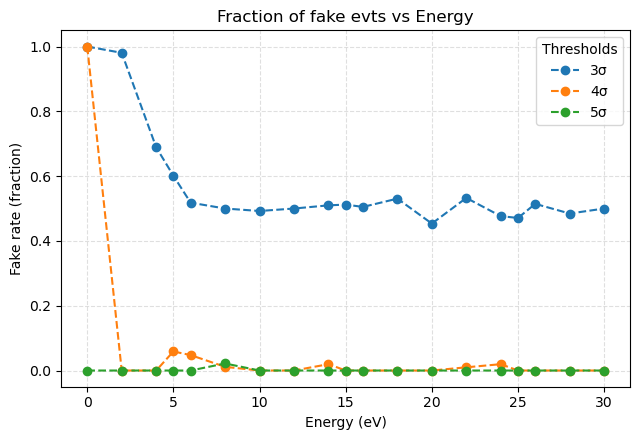


Fake rates:
Energy        3σ        4σ        5σ
0          1.0000   1.0000   0.0000
2          0.9806   0.0000   0.0000
4          0.6891   0.0000   0.0000
5          0.6012   0.0588   0.0000
6          0.5181   0.0476   0.0000
8          0.5000   0.0114   0.0217
10         0.4924   0.0000   0.0000
12         0.5000   0.0000   0.0000
14         0.5098   0.0196   0.0000
15         0.5122   0.0000   0.0000
16         0.5050   0.0000   0.0000
18         0.5305   0.0000   0.0000
20         0.4536   0.0000   0.0000
22         0.5327   0.0099   0.0000
24         0.4764   0.0196   0.0000
25         0.4709   0.0000   0.0000
26         0.5144   0.0000   0.0000
28         0.4845   0.0000   0.0000
30         0.5000   0.0000   0.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zstandard as zstd

# --------------------
# Settings
# --------------------
base_dir = Path("/ceph/dwong/trigger_samples/v2_300k")
import re
from pathlib import Path

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amp/max_amplitudes_energy_*.npy")
)

amp_tmpl = "max_amp/max_amplitudes_energy_{E}.npy"
mask_tmpl = "masks_energy_{E}.zst"

thresholds = [2.30, 3.07, 3.84]
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}

# --------------------
# Mask loader
# --------------------
def load_masks_from_zstd(input_path: Path, n_masks: int, mask_len: int) -> np.ndarray:
    bytes_per_row = (mask_len + 7) // 8
    expected = n_masks * bytes_per_row

    decomp = zstd.ZstdDecompressor()
    with open(input_path, "rb") as f:
        data = decomp.decompress(f.read())

    if len(data) != expected:
        raise ValueError(f"Decompressed mask size {len(data)} != expected {expected}")

    arr = np.frombuffer(data, dtype=np.uint8).reshape(n_masks, bytes_per_row)
    masks = np.unpackbits(arr, axis=1, bitorder="little", count=mask_len)
    return masks.astype(bool)

# --------------------
# Compute fake rates
# --------------------
fake_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    amp_path = base_dir / amp_tmpl.format(E=E)
    mask_path = base_dir / mask_tmpl.format(E=E)

    if not (amp_path.exists() and mask_path.exists()):
        print(f"[warn] Missing file for {E} eV, skipping")
        continue

    amps = np.load(amp_path)   # shape (100, 56)
    masks = load_masks_from_zstd(mask_path, n_masks=100, mask_len=56)  # (100, 56)

    if amps.shape != masks.shape:
        raise ValueError(f"Shape mismatch: amps {amps.shape}, masks {masks.shape}")

    available_E.append(E)

    for thr in thresholds:
        passed = amps >= thr
        true_passed = (passed & masks).sum()
        total_passed = passed.sum()
        fake_rate = 0.0 if total_passed == 0 else 1.0 - true_passed / total_passed
        fake_rates[thr].append(fake_rate)

# --------------------
# Plot
# --------------------
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, fake_rates[thr], "o--", label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Fake rate (fraction)")
plt.title("Fraction of fake evts vs Energy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --------------------
# Print table
# --------------------
print("\nFake rates:")
header = "Energy".ljust(8) + "  ".join([f"{labels[thr]:>8}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{fake_rates[thr][i]:>8.4f}")
    print(" ".join(row))


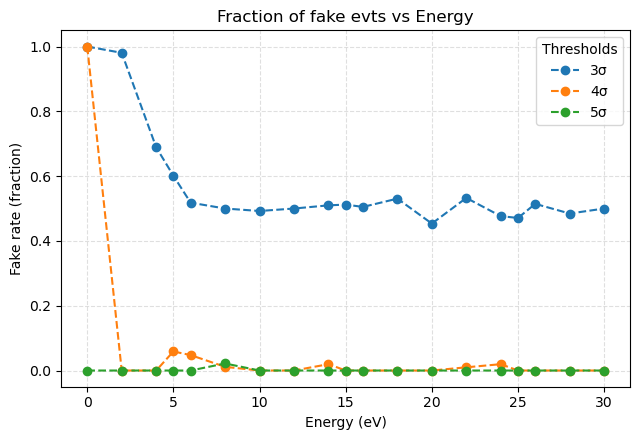


Fake rates:
Energy        3σ        4σ        5σ
0          1.0000   1.0000   0.0000
2          0.9806   0.0000   0.0000
4          0.6891   0.0000   0.0000
5          0.6012   0.0588   0.0000
6          0.5181   0.0476   0.0000
8          0.5000   0.0114   0.0217
10         0.4924   0.0000   0.0000
12         0.5000   0.0000   0.0000
14         0.5098   0.0196   0.0000
15         0.5122   0.0000   0.0000
16         0.5050   0.0000   0.0000
18         0.5305   0.0000   0.0000
20         0.4536   0.0000   0.0000
22         0.5327   0.0099   0.0000
24         0.4764   0.0196   0.0000
25         0.4709   0.0000   0.0000
26         0.5144   0.0000   0.0000
28         0.4845   0.0000   0.0000
30         0.5000   0.0000   0.0000

Counts @ 3σ threshold:
Energy   Triggered   True    Fake
0        108         0       108    
2        103         2       101    
4        119         37      82     
5        173         69      104    
6        166         80      86     
8        198         99

In [8]:
# --------------------
# Compute fake rates + counts
# --------------------
fake_rates = {thr: [] for thr in thresholds}
total_counts = {thr: [] for thr in thresholds}  # total triggered events
true_counts  = {thr: [] for thr in thresholds}  # true triggered events (per mask)
fake_counts  = {thr: [] for thr in thresholds}  # fake events = total - true
available_E = []

for E in energies:
    amp_path = base_dir / amp_tmpl.format(E=E)
    mask_path = base_dir / mask_tmpl.format(E=E)

    if not (amp_path.exists() and mask_path.exists()):
        print(f"[warn] Missing file for {E} eV, skipping")
        continue

    amps = np.load(amp_path)   # shape (100, 56)
    masks = load_masks_from_zstd(mask_path, n_masks=100, mask_len=56)  # (100, 56)

    if amps.shape != masks.shape:
        raise ValueError(f"Shape mismatch: amps {amps.shape}, masks {masks.shape}")

    available_E.append(E)

    for thr in thresholds:
        passed = amps >= thr
        true_passed = (passed & masks).sum()
        total_passed = passed.sum()
        fake = total_passed - true_passed

        true_counts[thr].append(int(true_passed))
        total_counts[thr].append(int(total_passed))
        fake_counts[thr].append(int(fake))

        fake_rate = 0.0 if total_passed == 0 else 1.0 - true_passed / total_passed
        fake_rates[thr].append(fake_rate)

# --------------------
# Plot (unchanged)
# --------------------
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, fake_rates[thr], "o--", label=labels[thr])
plt.xlabel("Energy (eV)")
plt.ylabel("Fake rate (fraction)")
plt.title("Fraction of fake evts vs Energy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --------------------
# Print fake-rate table (unchanged)
# --------------------
print("\nFake rates:")
header = "Energy".ljust(8) + "  ".join([f"{labels[thr]:>8}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{fake_rates[thr][i]:>8.4f}")
    print(" ".join(row))

# --------------------
# Print counts per threshold
# --------------------
for thr in thresholds:
    print(f"\nCounts @ {labels[thr]} threshold:")
    print("Energy   Triggered   True    Fake")
    for i, E in enumerate(available_E):
        t = total_counts[thr][i]
        tp = true_counts[thr][i]
        f = fake_counts[thr][i]
        print(f"{E:<8} {t:<11d} {tp:<7d} {f:<7d}")


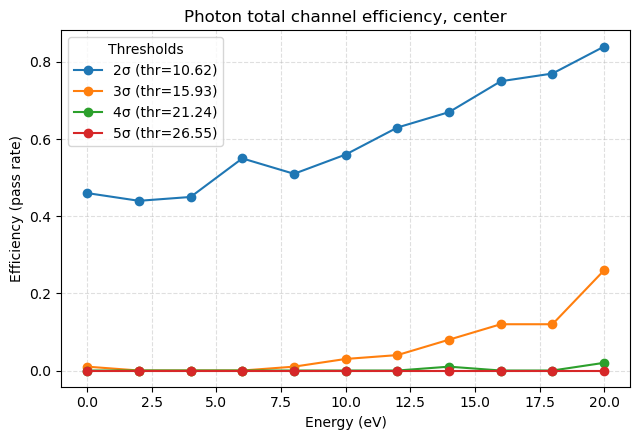


Pass rates:
Energy    2σ(thr=10.62)   3σ(thr=15.93)   4σ(thr=21.24)   5σ(thr=26.55)
0                0.4600         0.0100         0.0000         0.0000
2                0.4400         0.0000         0.0000         0.0000
4                0.4500         0.0000         0.0000         0.0000
6                0.5500         0.0000         0.0000         0.0000
8                0.5100         0.0100         0.0000         0.0000
10               0.5600         0.0300         0.0000         0.0000
12               0.6300         0.0400         0.0000         0.0000
14               0.6700         0.0800         0.0100         0.0000
16               0.7500         0.1200         0.0000         0.0000
18               0.7700         0.1200         0.0000         0.0000
20               0.8400         0.2600         0.0200         0.0000


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Settings ---
base_dir = Path("/home/dwong/DELight_mtr/flattened_sum/max_amp")
sigma = 5.31
sigma_multiples = [2, 3, 4, 5]
thresholds = {k: k * sigma for k in sigma_multiples}  # {2: 7.02, 3: 10.53, 4: 14.04, 5: 17.55}

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_vacsum_energy_*.npy")
)
file_tmpl = "max_amplitudes_vacsum_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {k: [] for k in sigma_multiples}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape: (repeats,) == (100,)
    data = np.asarray(data).squeeze()

    if data.ndim != 1:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected 1D array of length 100)")
    if data.shape[0] != 100:
        print(f"[warn] Unexpected length in {path}: {data.shape[0]} (expected 100)")

    available_E.append(E)
    for k, thr in thresholds.items():
        pass_rate = (data >= thr).mean()
        pass_rates[k].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for k in sigma_multiples:
    thr = thresholds[k]
    label = f"{k}σ (thr={thr:.2f})"
    plt.plot(available_E, pass_rates[k], marker="o", label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency (pass rate)")
plt.title(f"Photon total channel efficiency, center")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- (Optional) print a small table ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{k}σ(thr={thresholds[k]:.2f})".rjust(14) for k in sigma_multiples])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for k in sigma_multiples:
        row.append(f"{pass_rates[k][i]:>14.4f}")
    print(" ".join(row))
